In [2]:
import sqlite3
conn = sqlite3.connect("xyz.db")
cursor = conn.cursor()

cursor.execute("SELECT sqlite_version()")
version = cursor.fetchone()
print(version[0])

cursor.close()
conn.close()

3.46.0


In [5]:
import sqlite3

# Connect to SQLite DB
conn = sqlite3.connect("test1.db")
cursor = conn.cursor()

# Create table
cursor.execute('''
CREATE TABLE IF NOT EXISTS student (
    Name TEXT,
    RollNumber INTEGER,
    SAP_ID TEXT,
    Program TEXT,
    Marks INTEGER,
    Result TEXT
)''')

# Number of records to add
num_students = int(input("How many students? "))

for _ in range(num_students):
    name = input("Name: ")
    roll_number = int(input("Roll Number: "))
    sap_id = input("SAP ID: ")
    program = input("Program: ")
    marks = int(input("Marks: "))
    result = 'Pass' if marks >= 35 else 'Fail'

    # Insert record
    cursor.execute("INSERT INTO student VALUES (?, ?, ?, ?, ?, ?)",
                   (name, roll_number, sap_id, program, marks, result))

# Fetch and display all records
cursor.execute("SELECT * FROM student")
print(cursor.fetchall())

# Commit changes and close connection
conn.commit()



How many students?  1
Name:  tejas
Roll Number:  1
SAP ID:  a046
Program:  mca
Marks:  88


[('tejas', 1, 'a046', 'mca', 88, 'Pass')]


In [6]:
search_name = input("name: ")
search_sap = input("Sap: ")
cursor.execute("SELECT * FROM student WHERE name = ? AND SAP_ID = ?", (search_name, search_sap))
print(cursor.fetchall())

name:  tejas
Sap:  a046


[('tejas', 1, 'a046', 'mca', 88, 'Pass')]


In [9]:
update_name = input("Name to update: ")
usap = input("SAP ID to update: ")
newm = int(input("New marks: "))
newr = 'Pass' if newm >= 35 else 'Fail'

cursor.execute("UPDATE student SET Marks = ?, Result = ? WHERE Name = ? AND SAP_ID = ?",
               (newm, newr, update_name, usap))

conn.commit()
print("Record updated successfully.")


Name to update:  tejas
SAP ID to update:  a046
New marks:  99


Record updated successfully.


In [10]:
cursor.execute("SELECT * FROM student")
print(cursor.fetchall())


[('tejas', 1, 'a046', 'mca', 99, 'Pass')]


In [12]:
delete_record = input("")
cursor.execute("DELETE FROM student where NAME = ?", (delete_record,))
conn.commit()


cursor.execute("SELECT * FROM student")
print(cursor.fetchall())

 tejas


[]


In [15]:
import numpy as np

#0-d arrays with value 42

arr0 = np.array(42)

# 1-d arrays
arr1 = np.array([1,2,3])

#2-d array
arr2 = np.array([[1,2,3],[4,5,6]])
arr2

array([[1, 2, 3],
       [4, 5, 6]])

In [16]:
a=np.arange(0,7,2) #s = tart stop step
a

array([0, 2, 4, 6])

In [19]:
#np.zeros(), np.full()

# view() shallow copy -> same data, changes affect
# copy() independent copy -> same data, changes dont affect

# if nested lists use deepcopy -> same like copy()
import copy 
ar = np.array([[1,2,3],[4,5,6]])
deep=copy.deepcopy(ar)
deep[0,0]=100
deep

array([[100,   2,   3],
       [  4,   5,   6]])

In [ ]:
#np.median(var), np.std(var)
#np.dot(var1, var2) mul of two
#np.intersection1d(var), np.union1d(var)

import pandas as pd
df = pd.read_csv("OnlineRetail.csv", encoding='ISO-8859-1')
df

In [ ]:
df.rename(columns={"InvoiceNo": 'Invoice_Number', 'InvoiceDate': 'Invoice_Date'}, inplace=True)
df

In [ ]:
df['Country'].nunique()

In [ ]:
df['Invoice_Date']=pd.to_datetime(df['Invoice_Date'], errors='coerce')
df

In [ ]:
df.isnull().sum()

In [ ]:
df.info()

In [ ]:
df['Description'].nunique()

In [ ]:
df.fillna(df.select_dtypes(include=['object']).mode().iloc[0], inplace=True)

In [ ]:
df.isnull().sum()

In [ ]:
df['CustomerID'].nunique()

In [ ]:
print("Asa")

In [ ]:
print("Ad")

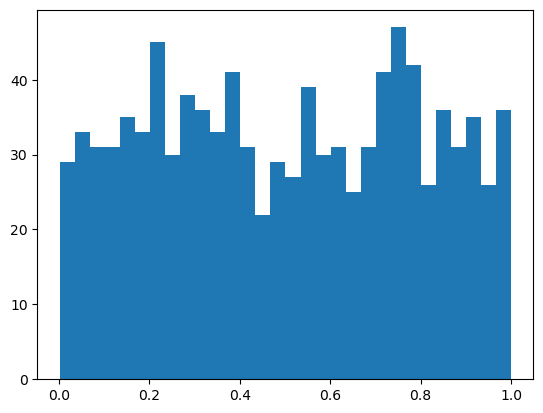

In [38]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.rand(1000)
plt.hist(data, bins=30)
plt.show()


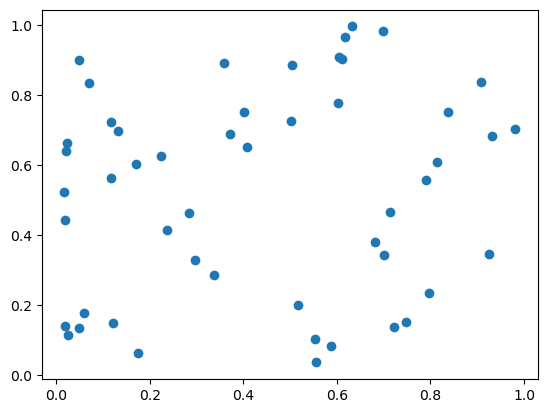

In [39]:
x = np.random.rand(50)
y = np.random.rand(50)

plt.scatter(x,y)

In [40]:
import seaborn as sns
import pandas as pd

titanic = sns.load_dataset("titanic")
total = len(titanic)
male_survived = titanic[(titanic['sex'] == 'male') & (titanic['survived'] == 1)].shape[0]
female_survived = titanic[(titanic['sex'] == 'female') & (titanic['survived'] == 1)].shape[0]

print(f"Male Survival: {(male_survived/total)*100:.2f}%")
print(f"Female Survival: {(female_survived/total)*100:.2f}%")


Male Survival: 12.23%
Female Survival: 26.15%
